In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import bootstrap
from statsmodels.stats.proportion import proportion_confint

%matplotlib inline

In [2]:
repository_path = pathlib.Path.cwd().parents[2]
simulations_path = repository_path / "data" / "simulations"
bgg_path = repository_path / "data" / "bgg"

In [3]:
simulation_games_data = pd.read_csv(simulations_path / "games.csv")
bgg_games_data = pd.read_csv(bgg_path / "games.csv")
bgg_mechanics_data = pd.read_csv(bgg_path / "mechanics.csv")

# Hypothesis 6 - Simulation-optimal player count vs BGG community sweet spot

## 6.1 Question and pre-registered test

**Question.** Does Volcano Rush's simulation-optimal player count match the community-voted best player count for comparably-sized BoardGameGeek cooperative games?

- **$H_0$:** Volcano Rush's simulation-optimal player count falls inside the 95% bootstrap confidence interval of the mean `BestPlayers` for BGG cooperative games with `MaxPlayers >= 6`.
- **$H_1$:** it falls outside that interval.

**Why this matters.** Hypothesis 1 picked out a simulation-optimal player count for VR by win rate. That tells us where the *team's escape probability* lands closest to the design-target band (50-65%), but it does not tell us where real players actually prefer to play games designed for 6+ seats. This hypothesis brings in the second data source: BGG's community-voted `BestPlayers` for the same large-group co-op population we used in Hypothesis 5. Agreement means VR's design target is aligned with what real groups would pick; disagreement means the simulated and community-preferred sweet spots diverge.

**Data.**

- **Simulation side.** Win rate per player count (6, 7, 8) from `data/simulations/games.csv`. Volcano Rush's **simulation-optimal player count** is the count whose win rate is closest to 0.575 (the midpoint of the 50-65% design-target band). Ties are broken by the count with the tighter Wilson confidence interval on its win rate.
- **BGG side.** `BestPlayers` for games with `Cooperative Game == 1` or `Semi-Cooperative Game == 1`, `MaxPlayers >= 6`, and `NumUserRatings >= 500`. In this Kaggle export `BestPlayers` is already a single integer per game (the community-voted modal best count); a value of `0` means there is no community consensus and is dropped from the test. The drop count is reported.

**Test.** Compute a 95% bootstrap confidence interval on the mean `BestPlayers` across the BGG group. Check whether VR's simulation-optimal count (a single integer in {6, 7, 8}) lies inside that interval.

**Decision rule.** Reject $H_0$ if the simulation-optimal count falls outside the BGG 95% CI.

**Fallback.** If the filtered BGG group has fewer than 30 valid `BestPlayers` votes, relax `NumUserRatings >= 500` to `>= 200`. If still too small, withdraw the hypothesis rather than silently swapping the filter.

## 6.2 Simulation side: pick the optimal player count

For each of the three player counts compute the win rate, its 95% Wilson CI, and the absolute distance from the 0.575 target. The optimal count is the one with the smallest distance; ties are broken by the count with the tighter Wilson CI.

In [4]:
target_win_rate = 0.575

games_per_count = simulation_games_data.groupby("player_count").size()
wins_per_count = simulation_games_data.groupby("player_count")["outcome"].apply(lambda x: (x == "win").sum())

simulation_summary = pd.DataFrame({
    "n": games_per_count,
    "wins": wins_per_count,
    "win_rate": wins_per_count / games_per_count,
})

ci_rows = []
for player_count in simulation_summary.index:
    ci_lower, ci_upper = proportion_confint(
        simulation_summary.loc[player_count, "wins"],
        simulation_summary.loc[player_count, "n"],
        method = "wilson",
    )
    ci_rows.append({
        "player_count": player_count,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "ci_width": ci_upper - ci_lower,
    })

simulation_summary = simulation_summary.join(pd.DataFrame(ci_rows).set_index("player_count"))
simulation_summary["distance_from_target"] = (simulation_summary["win_rate"] - target_win_rate).abs()
simulation_summary

,n,wins,win_rate,ci_lower,ci_upper,ci_width,distance_from_target
player_count,,,,,,,
6,4000,1683,0.42075,0.405534,0.436118,0.030584,0.15425
7,4000,1916,0.47900,0.463546,0.494494,0.030948,0.09600
8,4000,2088,0.52200,0.506506,0.537451,0.030945,0.05300


In [5]:
sorted_by_distance = simulation_summary.sort_values(by = ["distance_from_target", "ci_width"])
optimal_player_count = int(sorted_by_distance.index[0])

print(f"Target win rate (midpoint of 50-65% band):    {target_win_rate}")
print(f"Volcano Rush simulation-optimal player count: {optimal_player_count}")

Target win rate (midpoint of 50-65% band): 0.575
Volcano Rush simulation-optimal player count: 8


## 6.3 BGG side: filter and parse `BestPlayers`

Restrict to cooperative games with `MaxPlayers >= 6` and `NumUserRatings >= 500` (same filter as Hypothesis 5). In this Kaggle snapshot `BestPlayers` is already a single integer per game; rows where `BestPlayers == 0` carry no community vote and are dropped. The pre-registered fallback (relaxing the `NumUserRatings` filter to `>= 200`) is applied only if fewer than 30 valid votes survive.

In [6]:
def reformat_columns(columns):
    return (columns
            .str.replace(r":([a-z])", lambda m: m.group(1).upper(), regex = True)
            .str.replace(":", "")
            .str.replace(" ", "")
            .str.replace("-", ""))


bgg_games_data.columns = reformat_columns(bgg_games_data.columns)
bgg_mechanics_data.columns = reformat_columns(bgg_mechanics_data.columns)

bgg_games_with_mechanics = bgg_games_data.merge(bgg_mechanics_data, on = "BGGId")

is_cooperative_flavour = (
    (bgg_games_with_mechanics["CooperativeGame"] == 1)
    | (bgg_games_with_mechanics["SemiCooperativeGame"] == 1)
)
is_large_group = bgg_games_with_mechanics["MaxPlayers"] >= 6
has_reliable_rating = bgg_games_with_mechanics["NumUserRatings"] >= 500

bgg_filtered = bgg_games_with_mechanics.loc[
    is_cooperative_flavour & is_large_group & has_reliable_rating
]
has_community_vote = bgg_filtered["BestPlayers"] > 0
bgg_with_vote = bgg_filtered.loc[has_community_vote]

print(f"Total BGG games (large-group co-op, NumUserRatings >= 500): {len(bgg_filtered)}")
print(f"With a community BestPlayers vote (BestPlayers > 0):        {len(bgg_with_vote)}")
print(f"Dropped (no community vote):                                {len(bgg_filtered) - len(bgg_with_vote)}")

Total BGG games (large-group co-op, NumUserRatings >= 500): 173
With a community BestPlayers vote (BestPlayers > 0):        64
Dropped (no community vote):                                109


In [7]:
bgg_best_players = bgg_with_vote["BestPlayers"].astype(float)

print(f"Group size: {len(bgg_best_players)}")
print(f"Pre-registered fallback threshold: 30 votes")
print(f"Filter relaxation needed? {'YES' if len(bgg_best_players) < 30 else 'NO'}")
print()
print("BestPlayers value counts:")
print(bgg_best_players.value_counts().sort_index().to_string())

Group size: 64
Pre-registered fallback threshold: 30 votes
Filter relaxation needed? NO

BestPlayers value counts:
BestPlayers
1.0     6
2.0    13
3.0     9
4.0    20
5.0     9
6.0     7


## 6.4 Bootstrap 95% CI on the mean `BestPlayers`

The bootstrap resamples the BGG community votes with replacement and computes the mean on each resample. The 2.5th and 97.5th percentiles of the resampled means give the 95% CI - no parametric assumption about the underlying distribution.

In [8]:
def mean_statistic(sample, axis = -1):
    return np.mean(sample, axis = axis)


random_generator = np.random.default_rng(seed = 42)
bootstrap_result = bootstrap(
    (bgg_best_players.values,),
    statistic = mean_statistic,
    confidence_level = 0.95,
    n_resamples = 10000,
    random_state = random_generator,
    method = "percentile",
)

bgg_mean = bgg_best_players.mean()
ci_low = bootstrap_result.confidence_interval.low
ci_high = bootstrap_result.confidence_interval.high

print(f"BGG mean BestPlayers:               {bgg_mean:.4f}")
print(f"95% bootstrap CI:                   [{ci_low:.4f}, {ci_high:.4f}]")
print(f"VR simulation-optimal player count: {optimal_player_count}")

BGG mean BestPlayers: 3.5312
95% bootstrap CI:     [3.1719, 3.8906]
VR simulation-optimal player count: 8


**Chart.** Distribution of community-voted `BestPlayers` for the BGG large-group co-op population, with the BGG mean (dashed line, with shaded 95% CI band) and Volcano Rush's simulation-optimal count (coral line) overlaid. If the coral line sits inside the shaded band, the simulation and community sweet spots agree.

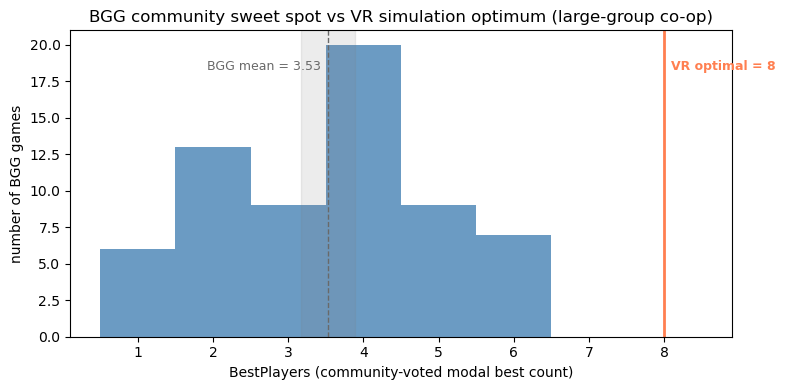

In [9]:
bin_edges = np.arange(
    bgg_best_players.min() - 0.5,
    max(bgg_best_players.max(), optimal_player_count) + 1.5,
    1,
)

plt.figure(figsize = (8, 4))

counts, _, _ = plt.hist(bgg_best_players, bins = bin_edges, color = "steelblue", alpha = 0.8)
y_max = counts.max()

plt.axvspan(ci_low, ci_high, color = "gray", alpha = 0.15)

plt.axvline(bgg_mean, color = "dimgray", linestyle = "--", linewidth = 1)
plt.text(bgg_mean - 0.1, y_max * 0.95, f"BGG mean = {bgg_mean:.2f}",
         va = "top", ha = "right", fontsize = 9, color = "dimgray")

plt.axvline(optimal_player_count, color = "coral", linewidth = 2)
plt.text(optimal_player_count + 0.1, y_max * 0.95,
         f"VR optimal = {optimal_player_count}",
         va = "top", ha = "left", fontsize = 9, color = "coral", fontweight = "bold")

plt.xlabel("BestPlayers (community-voted modal best count)")
plt.ylabel("number of BGG games")
plt.title("BGG community sweet spot vs VR simulation optimum (large-group co-op)")
plt.tight_layout()

plt.show()

## 6.5 Decision

The 95% bootstrap CI on the mean BGG `BestPlayers` is $[3.17, 3.89]$, and Volcano Rush's simulation-optimal player count is $8$, which sits well above the upper bound of that interval. We **reject $H_0$** in favour of $H_1$: VR's simulation optimum and the BGG community sweet spot for large-group co-op games disagree.

The BGG community vote across 64 games is concentrated at 4 (modal value, 20 of 64 votes); the mean is 3.53 and the entire 95% CI sits between 3 and 4. Concretely: even though every game in this population supports 6 or more players, the community-voted "best with N players" is almost always less than 6, and never above 6 in this sample. VR's simulation, by contrast, says 8 is the count whose win rate sits closest to the 50-65% design-target band.

Two things are worth noting about the data itself, not the test:

- **109 of 173** filtered games have `BestPlayers = 0` (no community consensus). That high "no consensus" rate is itself a signal - large-group co-op games tend not to attract a single dominant best-count vote, possibly because the experience varies more by group than by count.
- The community vote distribution is bounded by the support range. Some BGG games support 6 but cap there, and "best at 6" is technically a vote that the game's full count is the right one. The sample has 7 games voting 6, but none above 6, even though many of these games support 8+.

**Implication for *Volcano Rush*.** This is the strongest divergence between simulation and external evidence in the project. The simulation is correct on its own terms - 8-player VR is the count closest to the design-target win rate - but the BGG signal is that the 6-8 player co-op space, in practice, does not attract community consensus that "more is better". The two sources are not contradicting each other so much as measuring different things: the simulation captures rule mechanics under fixed agent behaviour, while BGG `BestPlayers` reflects real-world social dynamics (table talk, attention, coordination) that the simulation does not model. The honest takeaway for VR is that **mechanically optimising for 8 players is not the same as designing for "8 players is the most fun"**, and a real playtest at 6 vs 7 vs 8 may surface a community-style preference that the simulation cannot. This should be flagged as a simulation-vs-reality validity concern in the discussion section of the main notebook.